In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

1. Carga de datos

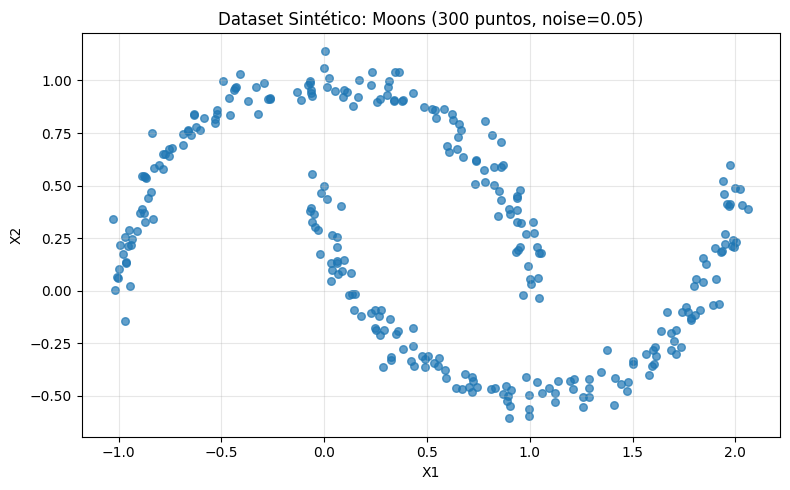

In [11]:
X, _ = make_moons(n_samples=300, noise=0.05)

# Visualización inicial
plt.figure(figsize=(8,5))
plt.scatter(X[:,0], X[:,1], s=30, alpha=0.7)
plt.title("Dataset Moons ")
plt.xlabel("X1"); plt.ylabel("X2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

2. Selección del hiperparámetro

🏆 Codo detectado en: 0.140


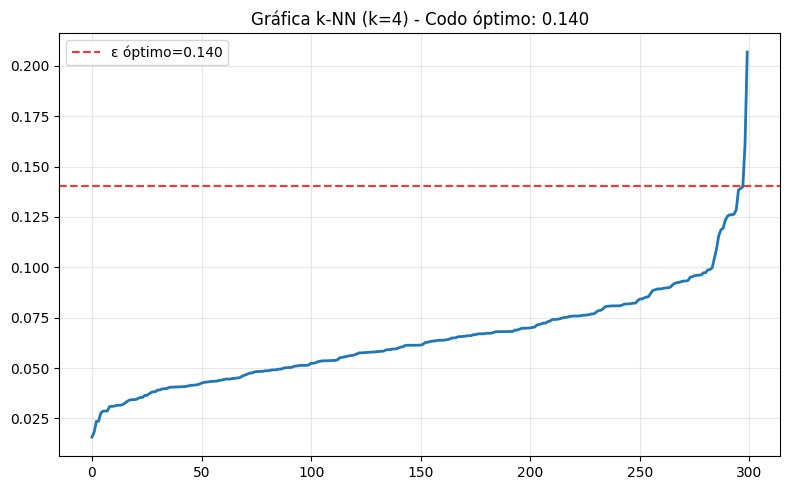

In [28]:

k = 4
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)
distances, indices = neighbors_fit.kneighbors(X)
distances = np.sort(distances[:, k-1], axis=0)

knee = distances[np.argmax(np.diff(np.diff(distances)))]  # Punto de inflexión

plt.figure(figsize=(8,5))
plt.plot(distances, linewidth=2)
plt.title(f"Gráfica k-NN (k={k}) - Codo óptimo: {knee:.3f}")
plt.axhline(y=knee, color='r', linestyle='--', alpha=0.8, label=f'ε óptimo={knee:.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

3. Hiperparámetros

In [30]:
eps = 0.10
min_samples = 4
print(f"eps = {eps}")
print(f"min_samples = {min_samples}")


eps = 0.1
min_samples = 4


4. DB-SCAN

In [17]:
modelo = DBSCAN(eps=eps, min_samples=min_samples)
labels = modelo.fit_predict(X)

5. Gráficas de resultados

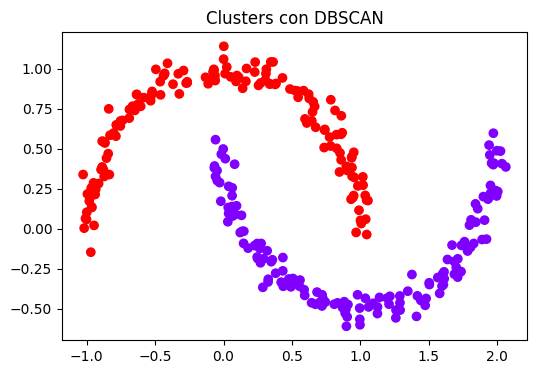

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='rainbow')
plt.title("Clusters con DBSCAN")
plt.show()

In [8]:

# Métricas clave
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = list(labels).count(-1)

print(f"Número de clusters: {n_clusters}")
print(f"Número de outliers: {n_outliers}")
print(f"Hiperparámetros usados: eps={eps}, min_samples={min_samples}")

Número de clusters: 2
Número de outliers: 0
Hiperparámetros usados: eps=0.2, min_samples=4


**1. ¿Para que valores se producen cambios? ¿Qué tipos de cambios?**
Condición de parada:

  a. Modifica uno o los hiperparámetros has un máximo de 5 veces e
  indica que cambios se han producido. Por ejmplo, cambios en el
  número de clusters, densidad de los clusters, etc.

In [32]:
print("BASELINE: eps=0.10, minPts=4 →", n_clusters, "clusters,", n_outliers, "outliers\n")

exps = [(0.08,4), (0.12,4), (0.10,6), (0.10,8), (0.15,4)]
baseline_clusters = n_clusters
baseline_outliers = n_outliers

for i, (e, m) in enumerate(exps, 1):
    mod = DBSCAN(eps=e, min_samples=m)
    labs = mod.fit_predict(X)
    nc = len(set(labs)) - (1 if -1 in labs else 0)
    no = list(labs).count(-1)

    cambio_c = "↑" if nc > baseline_clusters else "↓" if nc < baseline_clusters else "="
    cambio_o = "↑" if no > baseline_outliers else "="

    print(f"Exp{i}: eps={e}, minPts={m} → {nc}c{cambio_c}, {no}o{cambio_o}")

BASELINE: eps=0.10, minPts=4 → 2 clusters, 0 outliers

Exp1: eps=0.08, minPts=4 → 17c↑, 17o↑
Exp2: eps=0.12, minPts=4 → 4c↑, 2o↑
Exp3: eps=0.1, minPts=6 → 10c↑, 15o↑
Exp4: eps=0.1, minPts=8 → 14c↑, 32o↑
Exp5: eps=0.15, minPts=4 → 2c=, 1o↑


**2. ¿Para qué valores de los hiperparámetros se incrementa el número de
outliers?**

Condición de parada:
a. Si cuando se modifica 𝑀𝑖𝑛𝑃𝑡𝑠 𝑜 𝜀 se incrementa el número de
outliers. Entonces la respuesta son los últimos valores 𝑀𝑖𝑛𝑃𝑡𝑠 𝑦 𝜀

In [38]:
for i, (e, m) in enumerate(exps, 1):
    mod = DBSCAN(eps=e, min_samples=m)
    labs = mod.fit_predict(X)
    no = list(labs).count(-1)
    if no > baseline_outliers:
        print(f"Exp{i}: eps={e}, minPts={m} → {no} outliers (↑{no-baseline_outliers})")
    else:
        print(f"   Exp{i}: eps={e}, minPts={m} → {no} outliers")

incrementados = [(e,m) for e,m in exps if list(DBSCAN(eps=e,min_samples=m).fit_predict(X)).count(-1) > baseline_outliers]
if incrementados:
    print(f"eps={incrementados[-1][0]}, minPts={incrementados[-1][1]}")
else:
    print("No se modificó el número de outliers")

Exp1: eps=0.08, minPts=4 → 17 outliers (↑17)
Exp2: eps=0.12, minPts=4 → 2 outliers (↑2)
Exp3: eps=0.1, minPts=6 → 15 outliers (↑15)
Exp4: eps=0.1, minPts=8 → 32 outliers (↑32)
Exp5: eps=0.15, minPts=4 → 1 outliers (↑1)
eps=0.15, minPts=4
